In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df=pd.read_csv("../data/clean_text.csv")
df.head()

,title,text,subject,date,label,clean_text,text_length
0,Fourth ex-governor from Mexico's PRI arrested ...,MEXICO CITY (Reuters) - A former Mexican gover...,worldnews,"October 6, 2017",1,mexico city reuters a former mexican governor ...,2384
1,Russian lawyer who met Trump Jr. says ready to...,MOSCOW (Reuters) - The Russian lawyer who met ...,politicsNews,"July 19, 2017",1,moscow reuters the russian lawyer who met dona...,1647
2,Ukraine president: reforms to get harder as el...,KIEV (Reuters) - Ukrainian President Petro Por...,worldnews,"December 1, 2017",1,kiev reuters ukrainian president petro poroshe...,444
3,Woman accusing Trump of misconduct subpoenas p...,WASHINGTON (Reuters) - A woman who has said th...,politicsNews,"October 16, 2017",1,washington reuters a woman who has said that u...,2165
4,CIA's Brennan says tearing up Iran deal would ...,LONDON (Reuters) - Outgoing CIA Director John ...,politicsNews,"November 30, 2016",1,london reuters outgoing cia director john bren...,941


some articles contain only unclean value , after cleaniing they all will be vanished and in place of uncleaned value , nan will be replaced , so we should remove nan . that is , we should drop/remove the rows containing nan values

first check how many number of rows containing nan value

In [4]:
df["clean_text"].isna().sum()

632

remove rows with nan in the cleaned text

In [5]:
df=df.dropna(subset=["clean_text"])

this means , remove any row where clean text is missing

In [6]:
df = df.reset_index(drop=True)


seperate labels and features(input)

In [7]:
x=df["clean_text"]
y=df["label"]

create a vectorizer , here max_features=5000 means give top 5000 most important words

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)
x_tfidf = vectorizer.fit_transform(x)

In [9]:
x_tfidf.shape

(44266, 5000)

In [10]:
df["clean_text"]=df["clean_text"].astype(str)

In [11]:
vectorizer.get_feature_names_out()[:20]

array(['abandon', 'abandoned', 'abbas', 'abc', 'abdullah', 'abe',
       'abedin', 'ability', 'able', 'abortion', 'abortions', 'about',
       'above', 'abroad', 'absence', 'absolute', 'absolutely', 'absurd',
       'abu', 'abuse'], dtype=object)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x_tfidf,y,test_size=0.2,random_state=42,stratify=y)

train logistic regression model

In [14]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred=model.predict(x_test)

In [16]:
accuracy=accuracy_score(y_pred,y_test)
print("accuracy:",accuracy)

accuracy: 0.9894962728710187


classification report tells the pecision. f1 score, recall

In [17]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4549
           1       0.99      0.99      0.99      4305

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



In [18]:
confusion_matrix(y_pred,y_test)

array([[4513,   36],
       [  57, 4248]], dtype=int64)

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


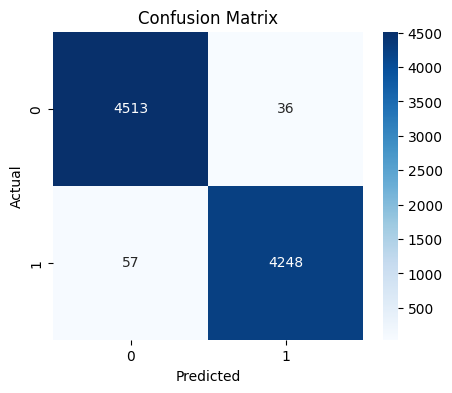

In [26]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_pred,y_test),annot=True , fmt="d" , cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Error Analysis

The confusion matrix indicates that the model correctly classifies
the majority of fake and real news articles. Most errors occur when
articles share similar language patterns, especially in short or
ambiguous texts.


In [27]:
from sklearn.naive_bayes import MultinomialNB

nb_model=MultinomialNB()
nb_model.fit(x_train,y_train)
y_pred_nb=nb_model.predict(x_test)

In [28]:
print("Naive Bayes Accuracy:",accuracy_score(y_pred_nb,y_test))
print(classification_report(y_pred_nb,y_test))

Naive Bayes Accuracy: 0.9383329568556584
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4564
           1       0.94      0.94      0.94      4290

    accuracy                           0.94      8854
   macro avg       0.94      0.94      0.94      8854
weighted avg       0.94      0.94      0.94      8854



## Day 9 – Model Comparison

Logistic Regression achieved higher accuracy and better F1-score
compared to Naive Bayes. Naive Bayes performed well but made more
misclassifications due to its strong independence assumptions.
Logistic Regression
was selected as the final model for deployment.

In [20]:
import pickle
with open("../model/logistic_model.pkl","wb") as f:
    pickle.dump(model,f)

with open("../model/tiidf_vectorizer.pkl","wb") as f:
    pickle.dump(vectorizer,f)